In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import pandas as pd
import datetime as dt

from src.data_preparation.input_preparation import prepare_input

In [17]:
df = pd.read_csv("ETT-small/ETTh1.csv")
df_prepped = prepare_input(df)

In [18]:
print(df_prepped.shape)

(17420, 8)


In [19]:
test_period_cutoff = dt.datetime(2017, 9, 1, 0, 0, 0)

df_train = df[df['date'] < test_period_cutoff]
df_test = df[df['date'] >= test_period_cutoff]

X_train = df_train.drop(columns=['date', 'OT'])
y_train = df_train['OT']

X_test = df_test.drop(columns=['date', 'OT'])
y_test = df_test['OT']

In [20]:
from statsmodels.tsa.stattools import kpss, adfuller
seasonal_diff = y_train.diff(24).dropna()
adfuller(seasonal_diff)

(np.float64(-16.782616521117273),
 np.float64(1.2606221481556559e-29),
 38,
 10185,
 {'1%': np.float64(-3.4309922139298674),
  '5%': np.float64(-2.8618238209224707),
  '10%': np.float64(-2.566921072734192)},
 np.float64(32106.534846181134))

In [21]:

stat, p, lags, crit = kpss(seasonal_diff.dropna(), regression='c')
print(f"KPSS stat: {stat}, p-value: {p}")

KPSS stat: 0.023132089899537994, p-value: 0.1


/tmp/ipykernel_23085/1945498275.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(seasonal_diff.dropna(), regression='c')


<Axes: >

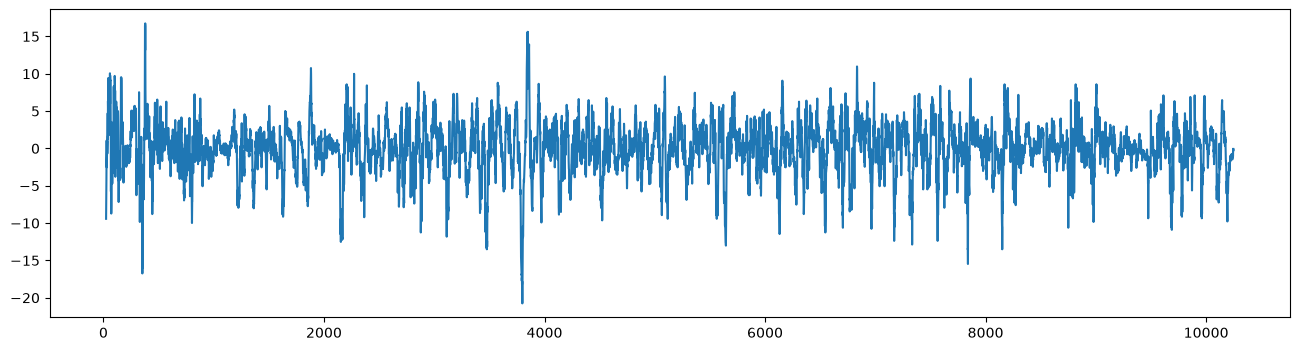

In [22]:
seasonal_diff.plot(figsize=(16, 4))

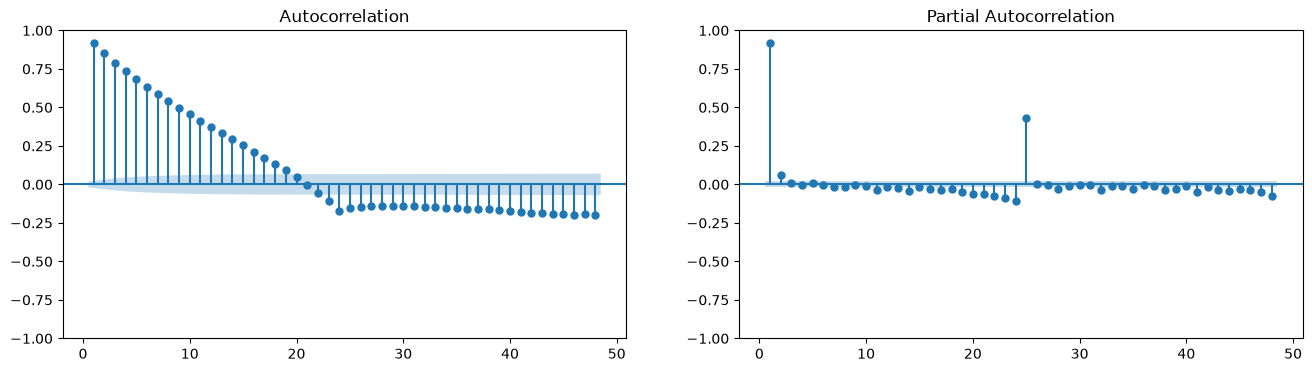

In [23]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Assume 'data' is your time series data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(seasonal_diff, ax=ax1, lags=48, zero = False)
plot_pacf(seasonal_diff, ax=ax2, lags=48, zero = False, method = 'ywm')
plt.show()

In [24]:
from statsmodels.tsa.stattools import acf, pacf
import numpy as np

n = len(seasonal_diff)
conf_band = 1.96 / np.sqrt(n)

pacf_vals = pacf(seasonal_diff, nlags=48, method='ywm')
for lag, val in enumerate(pacf_vals):
    flag = "***" if abs(val) > conf_band else ""
    print(f"lag {lag:2d}: {val: .3f} {flag}")

lag  0:  1.000 ***
lag  1:  0.917 ***
lag  2:  0.062 ***
lag  3:  0.010 
lag  4: -0.002 
lag  5:  0.010 
lag  6: -0.003 
lag  7: -0.018 
lag  8: -0.014 
lag  9: -0.004 
lag 10: -0.010 
lag 11: -0.034 ***
lag 12: -0.014 
lag 13: -0.022 ***
lag 14: -0.043 ***
lag 15: -0.015 
lag 16: -0.029 ***
lag 17: -0.038 ***
lag 18: -0.029 ***
lag 19: -0.050 ***
lag 20: -0.063 ***
lag 21: -0.065 ***
lag 22: -0.073 ***
lag 23: -0.087 ***
lag 24: -0.109 ***
lag 25:  0.429 ***
lag 26:  0.004 
lag 27: -0.003 
lag 28: -0.027 ***
lag 29: -0.008 
lag 30: -0.002 
lag 31: -0.005 
lag 32: -0.038 ***
lag 33: -0.008 
lag 34: -0.008 
lag 35: -0.028 ***
lag 36: -0.004 
lag 37: -0.009 
lag 38: -0.039 ***
lag 39: -0.030 ***
lag 40: -0.014 
lag 41: -0.050 ***
lag 42: -0.020 ***
lag 43: -0.036 ***
lag 44: -0.044 ***
lag 45: -0.032 ***
lag 46: -0.039 ***
lag 47: -0.048 ***
lag 48: -0.077 ***


In [ ]:
from src.model.arima import fit_arima
order = (1, 0, 1)
seasonal_order = (1, 1, 0, 24)
arima_model = fit_arima(y_train, X_train, order, seasonal_order)